# Data story: how trending YouTube ecosystems differ by country

This notebook is a **clean, presentation-ready** slice of the milestone analysis: one consistent country order, lean engagement metrics, cautious handling of rare categories, and an explicit **UTC** note for time-of-day charts.

**Run from the `milestone2/` folder** so paths to `../data/` (repo root) resolve correctly.


### Imports, load data, shared settings


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# --- presentation constants ---
# Fixed country order for every chart (ISO codes, Western Europe / English-speaking block first, then alphabetical within regions is avoided — use one memorable order):
COUNTRY_ORDER = ["US", "GB", "CA", "DE", "FR", "IN", "KR", "MX", "JP", "RU"]

# Categories with very few trending rows: percentages can swing — we flag them in labels and in text.
SPARSE_CATEGORY_NAMES = {"Movies", "Trailers", "Nonprofits & Activism", "Shows", "Short Movies"}
MIN_GLOBAL_CATEGORY = 4000   # minimum total trending *rows* globally to treat a category as "stable" in share plots
MIN_CELL_COUNT = 120         # minimum rows in a (country × category) cell to print a numeric % in heatmaps

data = "../data/"
df_us = pd.read_csv(data + "USvideos.csv")
df_ca = pd.read_csv(data + "CAvideos.csv")
df_de = pd.read_csv(data + "DEvideos.csv")
df_fr = pd.read_csv(data + "FRvideos.csv")
df_gb = pd.read_csv(data + "GBvideos.csv")
df_in = pd.read_csv(data + "INvideos.csv")
df_jp = pd.read_csv(data + "JPvideos.csv", encoding="utf-8-sig", encoding_errors="replace", engine="python")
df_kr = pd.read_csv(data + "KRvideos.csv", encoding="utf-8-sig", encoding_errors="replace", engine="python")
df_mx = pd.read_csv(data + "MXvideos.csv", encoding="utf-8-sig", encoding_errors="replace", engine="python")
df_ru = pd.read_csv(data + "RUvideos.csv", encoding="utf-8-sig", encoding_errors="replace", engine="python")

for d, c in [
    (df_us, "US"), (df_ca, "CA"), (df_de, "DE"), (df_fr, "FR"), (df_gb, "GB"),
    (df_in, "IN"), (df_jp, "JP"), (df_kr, "KR"), (df_mx, "MX"), (df_ru, "RU"),
]:
    d["country"] = c

df = pd.concat(
    [df_us, df_ca, df_de, df_fr, df_gb, df_in, df_jp, df_kr, df_mx, df_ru],
    ignore_index=True,
)
df = df.drop_duplicates()

category_map = {
    1: "Film & Animation", 2: "Autos & Vehicles", 10: "Music",
    15: "Pets & Animals", 17: "Sports", 18: "Short Movies",
    19: "Travel & Events", 20: "Gaming", 21: "Videoblogging",
    22: "People & Blogs", 23: "Comedy", 24: "Entertainment",
    25: "News & Politics", 26: "Howto & Style", 27: "Education",
    28: "Science & Technology", 29: "Nonprofits & Activism",
    30: "Movies", 43: "Shows", 44: "Trailers",
}
df["category"] = df["category_id"].map(category_map).fillna("Other")

df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")
df["publish_time"] = df["publish_time"].dt.tz_localize(None)
df["publish_hour"] = df["publish_time"].dt.hour

df["like_rate"] = df["likes"] / df["views"]
df["comment_rate"] = df["comment_count"] / df["views"]
df["like_dislike_ratio"] = df["likes"] / (df["dislikes"] + 1)

cat_totals = df.groupby("category").size().sort_values(ascending=False)
print("Trending rows per category (top 15):")
print(cat_totals.head(15).to_string())


Trending rows per category (top 15):
category
Entertainment            104567
People & Blogs            52297
Music                     41454
News & Politics           35746
Comedy                    26077
Sports                    23035
Film & Animation          20193
Howto & Style             18554
Gaming                    11063
Science & Technology       8068
Education                  7680
Autos & Vehicles           4678
Pets & Animals             4526
Nonprofits & Activism      2767
Travel & Events            1723


---

## 1. Category mix by country

**Start with the big picture:** each country’s trending list is a different blend of content types.

We show the **top categories by global volume** (columns). Categories with few trending rows overall can still appear here; cells with **very small sample sizes** are not annotated (see constants above). A **†** marks category axes that are globally sparse (below `MIN_GLOBAL_CATEGORY`).


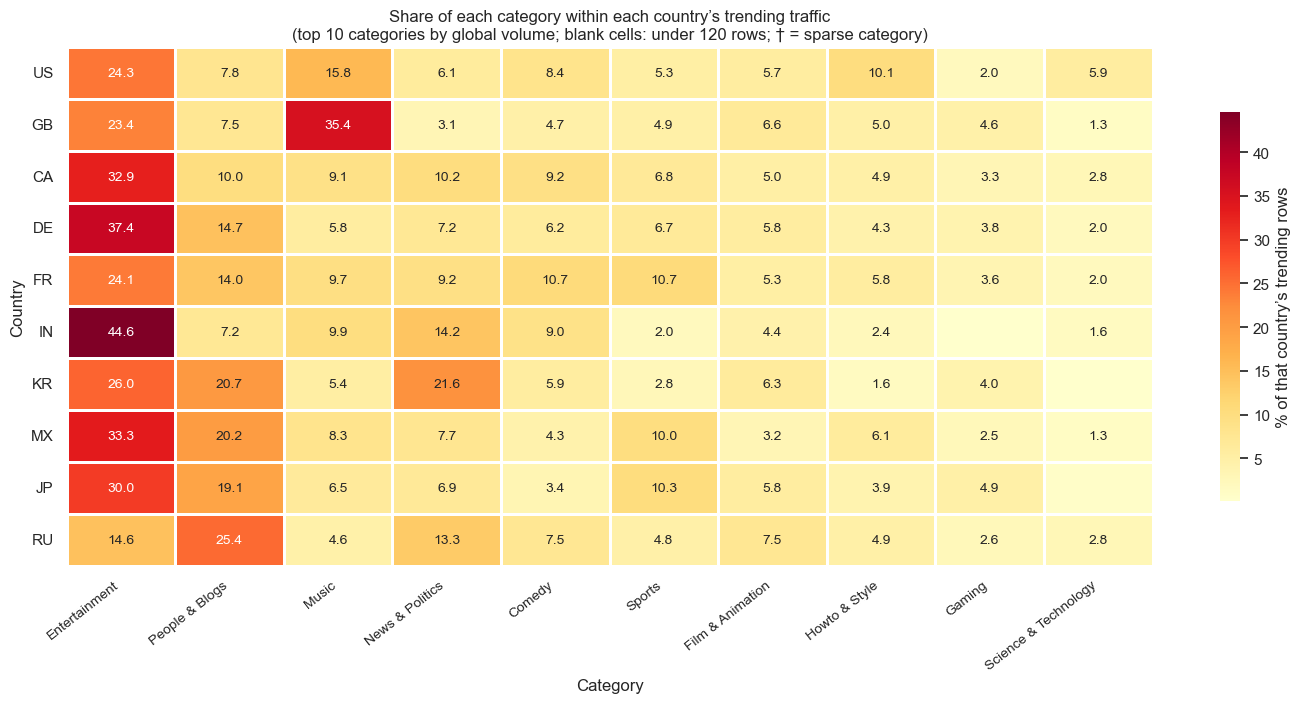

In [12]:
cat_country = df.groupby(["country", "category"]).size().unstack(fill_value=0)
cat_country = cat_country.reindex([c for c in COUNTRY_ORDER if c in cat_country.index])
cat_country_pct = cat_country.div(cat_country.sum(axis=1), axis=0) * 100

top_cats = cat_country.sum().nlargest(10).index.tolist()
heat_pct = cat_country_pct[top_cats]
heat_raw = cat_country[top_cats]

annot = heat_pct.copy().astype(object)
for i, country in enumerate(heat_pct.index):
    for j, cat in enumerate(heat_pct.columns):
        v = heat_pct.iloc[i, j]
        n = heat_raw.iloc[i, j]
        annot.iloc[i, j] = f"{v:.1f}" if n >= MIN_CELL_COUNT else ""

xlabels = []
for c in heat_pct.columns:
    flag = " †" if cat_totals.get(c, 0) < MIN_GLOBAL_CATEGORY or c in SPARSE_CATEGORY_NAMES else ""
    xlabels.append((c[:18] + "…") if len(c) > 20 else c + flag)

fig, ax = plt.subplots(figsize=(14.5, 7.2))
sns.heatmap(
    heat_pct.astype(float),
    annot=annot,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.85,
    linecolor="white",
    cbar_kws={"label": "% of that country’s trending rows", "shrink": 0.75},
    annot_kws={"size": 10},
    ax=ax,
)
ax.set_title(
    "Share of each category within each country’s trending traffic\n"
    f"(top {len(top_cats)} categories by global volume; blank cells: under {MIN_CELL_COUNT} rows; † = sparse category)"
)
ax.set_xlabel("Category")
ax.set_ylabel("Country")
ax.set_xticklabels(xlabels, rotation=38, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig("exploration_images/datastory_01_category_shares_by_country.png", dpi=160, bbox_inches="tight")
plt.show()


---

## 2. Engagement: comment rate and like / dislike ratio

**Then audience behaviour:** raw views reflect scale; these two metrics summarise *how people react* per view — **comment rate** (conversation) and **like/dislike ratio** (broad sentiment skew).

Countries appear in the **same order** as elsewhere (`COUNTRY_ORDER`).


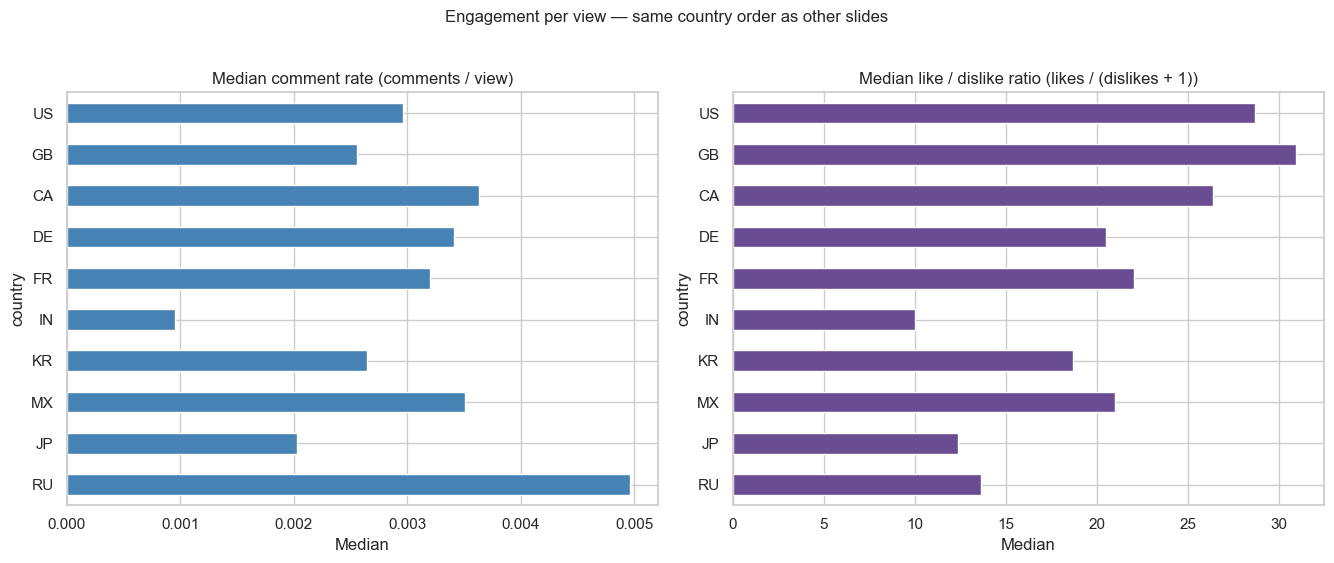

In [13]:
def median_by_country_order(df, col, order=COUNTRY_ORDER):
    s = df.groupby("country")[col].median().reindex([c for c in order if c in df["country"].values])
    return s


fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))

cr = median_by_country_order(df, "comment_rate")
cr.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Median comment rate (comments / view)")
axes[0].set_xlabel("Median")
axes[0].invert_yaxis()

ldr = median_by_country_order(df, "like_dislike_ratio")
ldr.plot.barh(ax=axes[1], color="#6a4c93")
axes[1].set_title("Median like / dislike ratio (likes / (dislikes + 1))")
axes[1].set_xlabel("Median")
axes[1].invert_yaxis()

plt.suptitle("Engagement per view — same country order as other slides", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("exploration_images/datastory_02_engagement_two_metrics.png", dpi=160, bbox_inches="tight")
plt.show()


---

## 3. When videos are published — **UTC hours**

**Timing:** creators (and platforms) follow different daily rhythms. 

> **Important:** `publish_hour` is derived from the timestamp in the dataset **without timezone conversion**. YouTube stores `publish_time` with a **Z** (UTC). So each hour bucket is **UTC**, not local wall-clock time in the country where the video was produced or where it trends. Comparisons across countries are fair in UTC, but they are **not** “9am local” in each place.

The heatmap uses **no per-cell numbers** (readability); colour encodes share within each country’s row.


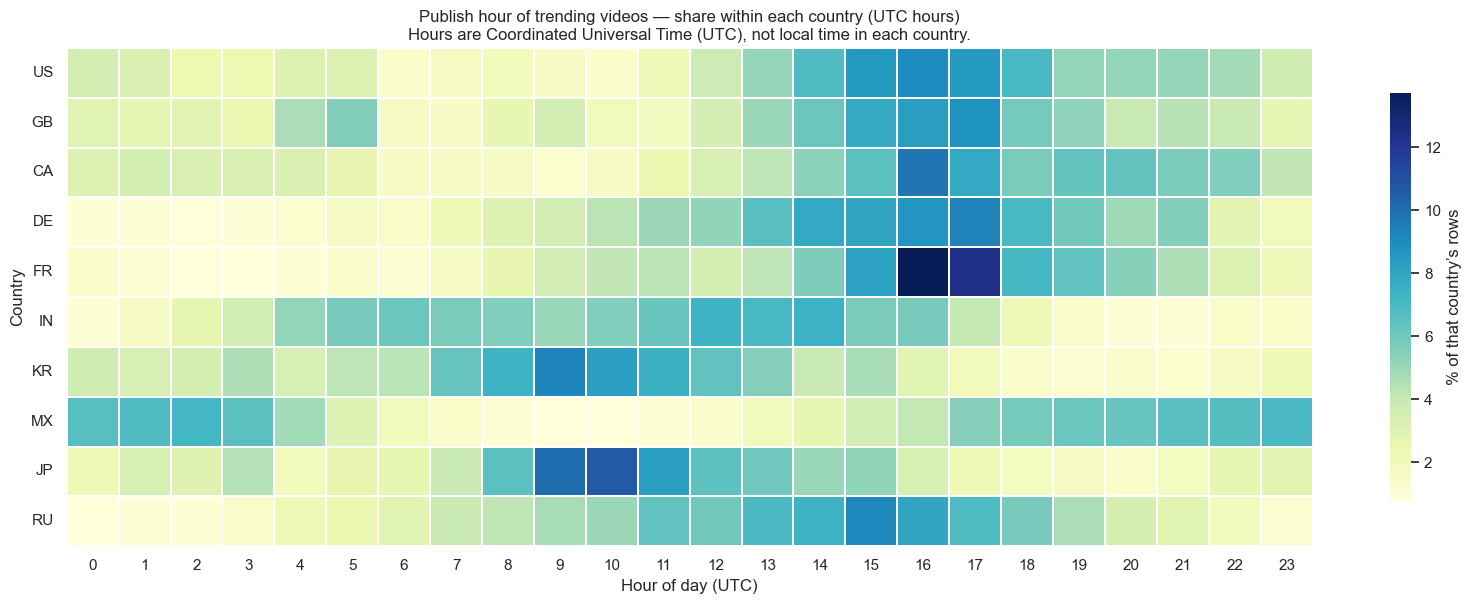

In [14]:
hour_country = (
    df.groupby(["country", "publish_hour"])
    .size()
    .unstack(fill_value=0)
)
hour_country = hour_country.reindex([c for c in COUNTRY_ORDER if c in hour_country.index])
hour_country_pct = hour_country.div(hour_country.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16.5, 6.2))
sns.heatmap(
    hour_country_pct,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.35,
    linecolor="white",
    cbar_kws={"label": "% of that country’s rows", "shrink": 0.82},
    ax=ax,
)
ax.set_title(
    "Publish hour of trending videos — share within each country (UTC hours)\n"
    "Hours are Coordinated Universal Time (UTC), not local time in each country."
)
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Country")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig("exploration_images/datastory_03_publish_hour_utc.png", dpi=160, bbox_inches="tight")
plt.show()


---

## 4. Country mix *within* each category

**Reverse perspective:** for each content type, where do trending rows come from? This deepens the geography–content story from section 1.

Rows are **categories** (enough volume to be readable). We exclude categories with **global row count** below `MIN_GLOBAL_CATEGORY` from this heatmap so sparse types do not dominate with noisy percentages. Remaining categories are ordered by volume. **Annotations** only appear when the underlying row count ≥ `MIN_CELL_COUNT`.


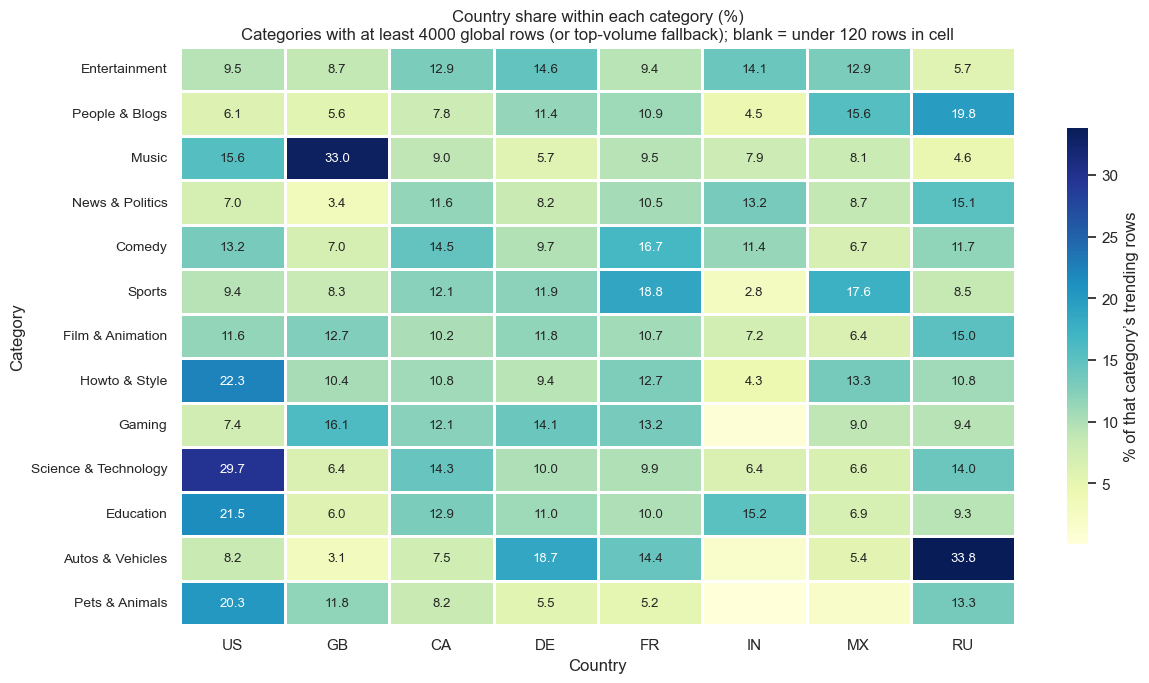

In [15]:
country_cat = df.groupby(["category", "country"]).size().unstack(fill_value=0)
country_cat_pct = country_cat.div(country_cat.sum(axis=1), axis=0) * 100

eligible_cats = cat_totals[cat_totals >= MIN_GLOBAL_CATEGORY].index.tolist()
if len(eligible_cats) < 8:
    eligible_cats = cat_totals.head(12).index.tolist()

country_cat_pct = country_cat_pct.loc[eligible_cats]
country_cat_raw = country_cat.loc[eligible_cats]

vol_country = df["country"].value_counts()
top_countries = vol_country.nlargest(8).index.tolist()
top_countries = sorted(top_countries, key=lambda c: COUNTRY_ORDER.index(c) if c in COUNTRY_ORDER else 99)

sub_pct = country_cat_pct[top_countries]
sub_raw = country_cat_raw[top_countries]

annot2 = sub_pct.copy().astype(object)
for i, cat in enumerate(sub_pct.index):
    for j, country in enumerate(sub_pct.columns):
        v = sub_pct.iloc[i, j]
        n = sub_raw.iloc[i, j]
        annot2.iloc[i, j] = f"{v:.1f}" if n >= MIN_CELL_COUNT else ""

fig_h = max(7.0, 0.42 * len(sub_pct))
fig, ax = plt.subplots(figsize=(12.5, fig_h))
sns.heatmap(
    sub_pct.astype(float),
    annot=annot2,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.9,
    linecolor="white",
    cbar_kws={"label": "% of that category’s trending rows", "shrink": 0.72},
    annot_kws={"size": 9.5},
    ax=ax,
)
ax.set_title(
    "Country share within each category (%)\n"
    f"Categories with at least {MIN_GLOBAL_CATEGORY} global rows (or top-volume fallback); blank = under {MIN_CELL_COUNT} rows in cell"
)
ax.set_xlabel("Country")
ax.set_ylabel("Category")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.set_yticklabels([t.get_text()[:32] for t in ax.get_yticklabels()], rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("exploration_images/datastory_04_country_share_within_category.png", dpi=160, bbox_inches="tight")
plt.show()


---

### Export list of figures (for slides)

- `exploration_images/datastory_01_category_shares_by_country.png`
- `exploration_images/datastory_02_engagement_two_metrics.png`
- `exploration_images/datastory_03_publish_hour_utc.png`
- `exploration_images/datastory_04_country_share_within_category.png`
